# 🎬 IMDB Sentiment Dataset — Beginner Data Science Project

**Dataset:** 50,000 IMDB movie reviews (positive / negative)  
**Tools:** NumPy · Pandas · Matplotlib  
**Goal:** Clean, explore, and visualise the dataset step by step

---
> 💡 **How to use this notebook:** Run each cell one by one (Shift + Enter).  
> Each section is independent — read the explanation, then run the code.


---
## 📦 Part 1 — Import Libraries

We start by importing the three main libraries we need:
- **NumPy** → for number crunching (arrays, math)
- **Pandas** → for working with tabular data (like Excel in Python)
- **Matplotlib** → for drawing charts and graphs

> ⚠️ **Possible Error:** `ModuleNotFoundError: No module named 'numpy'`  
> **Fix:** Run `pip install numpy pandas matplotlib` in your terminal, then restart the kernel.


In [3]:
# ── Import Libraries ──────────────────────────────────────────────────────────

import numpy as np          # Numerical operations
import pandas as pd         # Data manipulation
import matplotlib.pyplot as plt  # Plotting charts
import re                   # Regular expressions (for cleaning text)

# Tell Matplotlib to show charts inside the notebook
%matplotlib inline

# Optional: make plots look a little nicer
plt.rcParams['figure.figsize'] = (8, 5)
plt.rcParams['axes.spines.top']   = False
plt.rcParams['axes.spines.right'] = False

print("✅ All libraries imported successfully!")
print(f"   NumPy   version: {np.__version__}")
print(f"   Pandas  version: {pd.__version__}")


✅ All libraries imported successfully!
   NumPy   version: 2.4.3
   Pandas  version: 3.0.3


---
## 📂 Part 2 — Load the Dataset

We load the CSV file into a **DataFrame** — think of it as a table with rows and columns.

> ⚠️ **Possible Error:** `FileNotFoundError: IMDB_Dataset.csv not found`  
> **Fix:** Make sure `IMDB_Dataset.csv` is in the **same folder** as this notebook.  
> Or use the full path, e.g. `pd.read_csv('C:/Users/YourName/Downloads/IMDB_Dataset.csv')`


In [4]:
# ── Load Dataset ──────────────────────────────────────────────────────────────

# Read the CSV file into a DataFrame called 'df'
df = pd.read_csv(r'C:\Users\STRIKER\Downloads\archive\IMDB Dataset.csv')

# Quick check — show the first 5 rows
print("✅ Dataset loaded!")

print(f"   Rows: {df.shape[0]:,}   |   Columns: {df.shape[1]}")
df.head()

✅ Dataset loaded!
   Rows: 50,000   |   Columns: 2


,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


---
## 🔍 Part 3 — Dataset Overview

Before we do anything, we need to *understand* our data:
- How many rows and columns are there?
- What data types are stored?
- Are there any missing values?


In [5]:
# ── 3a: Shape ─────────────────────────────────────────────────────────────────
# .shape returns (number_of_rows, number_of_columns)

rows, cols = df.shape
print(f"📊 The dataset has {rows:,} rows and {cols} columns.")


📊 The dataset has 50,000 rows and 2 columns.


In [6]:
# ── 3b: Column names and data types ──────────────────────────────────────────
# .info() shows column names, non-null counts, and data types

df.info()


<class 'pandas.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   review     50000 non-null  str  
 1   sentiment  50000 non-null  str  
dtypes: str(2)
memory usage: 781.4 KB


In [7]:
# ── 3c: First & last rows ─────────────────────────────────────────────────────

print("=== First 3 rows ===")
print(df.head(3).to_string())
print()
print("=== Last 3 rows ===")
print(df.tail(3).to_string())


=== First 3 rows ===
                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                   

In [8]:
# ── 3d: Unique values in each column ─────────────────────────────────────────

print("Unique values per column:")
for col in df.columns:
    n = df[col].nunique()
    print(f"  '{col}' → {n:,} unique values")

print()
print("Sentiment value counts:")
print(df['sentiment'].value_counts())


Unique values per column:
  'review' → 49,582 unique values
  'sentiment' → 2 unique values

Sentiment value counts:
sentiment
positive    25000
negative    25000
Name: count, dtype: int64


In [9]:
# ── 3e: Check for missing values ─────────────────────────────────────────────
# .isnull().sum() counts how many NaN (empty) cells are in each column

missing = df.isnull().sum()
print("Missing values per column:")
print(missing)

if missing.sum() == 0:
    print("\n✅ No missing values found!")
else:
    print("\n⚠️  There are missing values — we will fix them in Part 4.")


Missing values per column:
review       0
sentiment    0
dtype: int64

✅ No missing values found!


In [10]:
# ── 3f: Check for duplicate rows ─────────────────────────────────────────────

num_duplicates = df.duplicated().sum()
print(f"Duplicate rows found: {num_duplicates:,}")


Duplicate rows found: 418


---
## 🧹 Part 4 — Data Cleaning

Raw data is rarely perfect. In this part we will:
1. Remove duplicate rows
2. Clean the review text (remove HTML tags, extra spaces)
3. Verify data types are correct

> 💡 We always work on a **copy** of the original data so we don't lose anything.


In [11]:
# ── 4a: Make a working copy ───────────────────────────────────────────────────
# Good practice: keep the original 'df' untouched

df_clean = df.copy()
print(f"Working copy created — shape: {df_clean.shape}")


Working copy created — shape: (50000, 2)


In [12]:
# ── 4b: Remove duplicate rows ────────────────────────────────────────────────
# Duplicate rows can distort our analysis — remove them

before = len(df_clean)
df_clean = df_clean.drop_duplicates()
after  = len(df_clean)

print(f"Rows before removing duplicates : {before:,}")
print(f"Rows after  removing duplicates : {after:,}")
print(f"Duplicates removed              : {before - after:,}")


Rows before removing duplicates : 50,000
Rows after  removing duplicates : 49,582
Duplicates removed              : 418


In [13]:
# ── 4c: Handle missing values ─────────────────────────────────────────────────
# The dataset has no missing values, but this is how you'd handle them:

# --- Drop rows where ANY column is empty ---
# df_clean = df_clean.dropna()

# --- Fill missing text with a placeholder ---
# df_clean['review'] = df_clean['review'].fillna('no review')

# Since we have no missing values, just confirm it's still clean:
print("Missing values after cleaning:")
print(df_clean.isnull().sum())
print("\n✅ No missing values — nothing to fill.")


Missing values after cleaning:
review       0
sentiment    0
dtype: int64

✅ No missing values — nothing to fill.


In [14]:
# ── 4d: Clean the review text ─────────────────────────────────────────────────
# Reviews contain HTML tags like <br />.  We remove them with a simple function.

def clean_text(text):
    """Remove HTML tags and extra whitespace from a string."""
    # Remove anything between < and > (HTML tags)
    text = re.sub(r'<.*?>', ' ', text)
    # Replace multiple spaces with a single space
    text = re.sub(r'\s+', ' ', text)
    # Remove leading/trailing whitespace
    text = text.strip()
    return text

# Apply the function to every row in the 'review' column
df_clean['review'] = df_clean['review'].apply(clean_text)

# Quick check
print("Sample review after cleaning:")
print(df_clean['review'].iloc[0][:300])


Sample review after cleaning:
One of the other reviewers has mentioned that after watching just 1 Oz episode you'll be hooked. They are right, as this is exactly what happened with me. The first thing that struck me about Oz was its brutality and unflinching scenes of violence, which set in right from the word GO. Trust me, this


In [15]:
# ── 4e: Fix / verify data types ──────────────────────────────────────────────
# Both columns should be strings (object type in pandas)

print("Data types:")
print(df_clean.dtypes)

# Convert to lowercase just to be safe (avoids 'Positive' ≠ 'positive' issues)
df_clean['sentiment'] = df_clean['sentiment'].str.lower().str.strip()

print("\nSentiment unique values after normalisation:")
print(df_clean['sentiment'].unique())


Data types:
review       str
sentiment    str
dtype: object

Sentiment unique values after normalisation:
<StringArray>
['positive', 'negative']
Length: 2, dtype: str


In [16]:
# ── 4f: Summary after cleaning ────────────────────────────────────────────────

print("=== Cleaning Summary ===")
print(f"Original rows : {len(df):,}")
print(f"Clean rows    : {len(df_clean):,}")
print(f"Rows removed  : {len(df) - len(df_clean):,}")


=== Cleaning Summary ===
Original rows : 50,000
Clean rows    : 49,582
Rows removed  : 418


---
## ⚙️ Part 5 — Data Preprocessing

Before analysis we need to prepare our data:
- **Encoding** — convert text labels ("positive"/"negative") to numbers (1/0)
- **Add a feature** — calculate review length (useful for EDA)
- **Scaling** — not needed here because we won't run a distance-based ML model,  
  but we show how it works for learning purposes


In [17]:
# ── 5a: Label Encoding ───────────────────────────────────────────────────────
# Machine learning models need numbers, not words.
# positive → 1 | negative → 0

df_clean['sentiment_encoded'] = df_clean['sentiment'].map({'positive': 1, 'negative': 0})

print("Encoding preview:")
print(df_clean[['sentiment', 'sentiment_encoded']].head(6))
print()
print("Encoded value counts:")
print(df_clean['sentiment_encoded'].value_counts())


Encoding preview:
  sentiment  sentiment_encoded
0  positive                  1
1  positive                  1
2  positive                  1
3  negative                  0
4  positive                  1
5  positive                  1

Encoded value counts:
sentiment_encoded
1    24884
0    24698
Name: count, dtype: int64


In [18]:
# ── 5b: Feature Engineering — review length ──────────────────────────────────
# 'Review length' = number of characters in the review.
# This is a new column we create from existing data — very common in NLP!

df_clean['review_length'] = df_clean['review'].str.len()

print("Review length stats:")
print(df_clean['review_length'].describe().round(1))


Review length stats:
count    49582.0
mean      1288.0
std        973.5
min         32.0
25%        690.0
50%        956.0
75%       1562.0
max      13593.0
Name: review_length, dtype: float64


In [19]:
# ── 5c: Word count per review ────────────────────────────────────────────────
# Another useful feature: how many words are in each review?

df_clean['word_count'] = df_clean['review'].str.split().str.len()

print("Word count stats:")
print(df_clean['word_count'].describe().round(1))


Word count stats:
count    49582.0
mean       229.1
std        169.8
min          4.0
25%        125.0
50%        172.0
75%        278.0
max       2459.0
Name: word_count, dtype: float64


In [20]:
# ── 5d: Scaling (demonstration) ──────────────────────────────────────────────
# Min-Max scaling squeezes values into the range [0, 1].
# Useful before applying KNN, SVM, or neural networks.
# We scale 'review_length' just to show how it works.

# Formula:  scaled = (value - min) / (max - min)

col = df_clean['review_length']
review_length_scaled = (col - col.min()) / (col.max() - col.min())

print("Original review_length — first 5:")
print(col.head().values)
print()
print("Scaled review_length  — first 5:")
print(review_length_scaled.head().round(4).values)
print()
print(f"Scaled range: {review_length_scaled.min():.2f}  to  {review_length_scaled.max():.2f}")


Original review_length — first 5:
[1728  962  904  715 1272]

Scaled review_length  — first 5:
[0.1251 0.0686 0.0643 0.0504 0.0914]

Scaled range: 0.00  to  1.00


---
## 📊 Part 6 — Basic Exploratory Data Analysis (EDA)

EDA means getting to *know* your data by asking simple questions:
- How is sentiment distributed?
- What is the average review length?
- Are positive reviews longer than negative ones?


In [21]:
# ── 6a: Sentiment distribution ───────────────────────────────────────────────

sentiment_counts = df_clean['sentiment'].value_counts()
print("Sentiment Distribution:")
print(sentiment_counts)
print()

total = len(df_clean)
for label, count in sentiment_counts.items():
    pct = count / total * 100
    print(f"  {label.capitalize():10s} → {count:,} reviews  ({pct:.1f}%)")


Sentiment Distribution:
sentiment
positive    24884
negative    24698
Name: count, dtype: int64

  Positive   → 24,884 reviews  (50.2%)
  Negative   → 24,698 reviews  (49.8%)


In [22]:
# ── 6b: Review length stats by sentiment ─────────────────────────────────────

length_by_sentiment = df_clean.groupby('sentiment')['review_length'].describe().round(1)
print("Review Length Statistics by Sentiment:")
print(length_by_sentiment)


Review Length Statistics by Sentiment:
             count    mean     std   min    25%    50%     75%      max
sentiment                                                              
negative   24698.0  1271.5   929.0  32.0  697.0  958.0  1538.0   8698.0
positive   24884.0  1304.4  1015.5  65.0  683.0  953.0  1587.0  13593.0


In [23]:
# ── 6c: Word count stats by sentiment ────────────────────────────────────────

word_by_sentiment = df_clean.groupby('sentiment')['word_count'].mean().round(1)
print("Average Word Count by Sentiment:")
print(word_by_sentiment)
print()
# Are longer reviews more positive or negative?
diff = word_by_sentiment['positive'] - word_by_sentiment['negative']
print(f"Positive reviews are on average {abs(diff):.1f} words {'longer' if diff > 0 else 'shorter'} than negative ones.")


Average Word Count by Sentiment:
sentiment
negative    227.2
positive    230.9
Name: word_count, dtype: float64

Positive reviews are on average 3.7 words longer than negative ones.


In [24]:
# ── 6d: Correlation between word count and review length ─────────────────────
# Correlation tells us: if word_count goes up, does review_length also go up?
# Value near +1 → strong positive relationship

correlation = df_clean['word_count'].corr(df_clean['review_length'])
print(f"Correlation between word count and review length: {correlation:.4f}")
print("(Close to 1.0 means they are strongly related — which makes sense!)")


Correlation between word count and review length: 0.9968
(Close to 1.0 means they are strongly related — which makes sense!)


---
## 📈 Part 7 — Visualisations with Matplotlib

We will create four charts:
1. **Bar Chart** — sentiment counts
2. **Histogram** — distribution of review lengths
3. **Pie Chart** — positive vs negative share
4. **Scatter Plot** — word count vs review length

> 💡 Each chart teaches you a different Matplotlib concept.


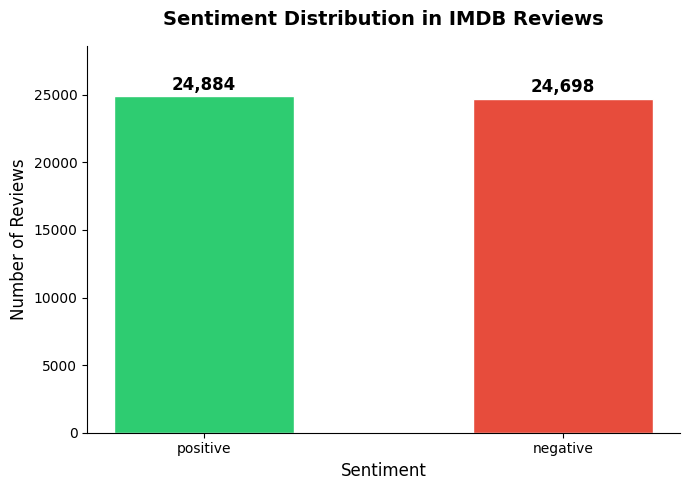

📁 Saved as chart_01_bar_sentiment.png


In [25]:
# ── 7a: Bar Chart — Sentiment Counts ─────────────────────────────────────────
# A bar chart is great for comparing categories.

sentiment_counts = df_clean['sentiment'].value_counts()

fig, ax = plt.subplots(figsize=(7, 5))

# Draw bars
bars = ax.bar(
    sentiment_counts.index,          # x-axis labels
    sentiment_counts.values,         # bar heights
    color=['#2ecc71', '#e74c3c'],    # green for positive, red for negative
    edgecolor='white',
    width=0.5
)

# Add value labels on top of each bar
for bar in bars:
    height = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width() / 2,   # x position (centre of bar)
        height + 200,                          # y position (just above bar)
        f'{height:,}',                         # text to show
        ha='center', va='bottom', fontsize=12, fontweight='bold'
    )

# Labels and title
ax.set_title('Sentiment Distribution in IMDB Reviews', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Sentiment', fontsize=12)
ax.set_ylabel('Number of Reviews', fontsize=12)
ax.set_ylim(0, max(sentiment_counts.values) * 1.15)   # a bit of headroom

plt.tight_layout()
plt.savefig('chart_01_bar_sentiment.png', dpi=150)
plt.show()
print("📁 Saved as chart_01_bar_sentiment.png")


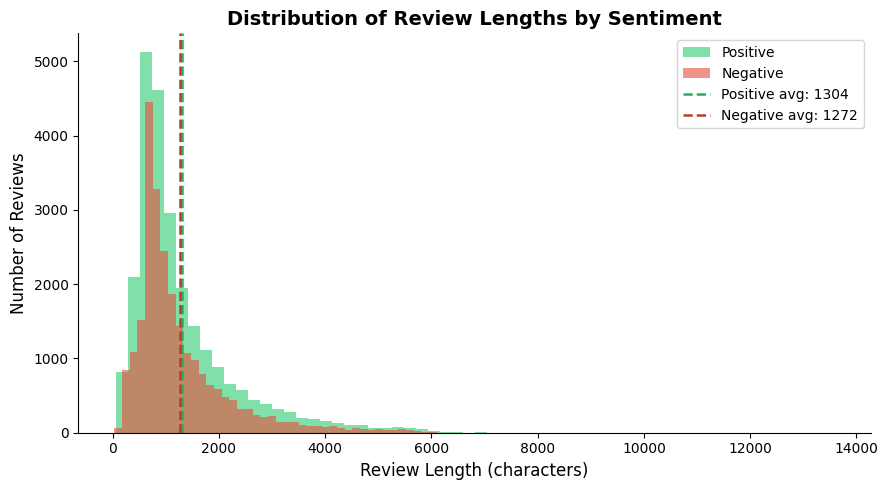

📁 Saved as chart_02_histogram_review_length.png


In [26]:
# ── 7b: Histogram — Review Length Distribution ───────────────────────────────
# A histogram shows HOW data is spread out.
# Each bar = a range of values; height = how many reviews fall in that range.

fig, ax = plt.subplots(figsize=(9, 5))

# Separate positive and negative reviews
pos_lengths = df_clean.loc[df_clean['sentiment'] == 'positive', 'review_length']
neg_lengths = df_clean.loc[df_clean['sentiment'] == 'negative', 'review_length']

# Draw overlapping histograms (alpha makes them semi-transparent)
ax.hist(pos_lengths, bins=60, color='#2ecc71', alpha=0.6, label='Positive', edgecolor='none')
ax.hist(neg_lengths, bins=60, color='#e74c3c', alpha=0.6, label='Negative', edgecolor='none')

# Mark the averages with vertical lines
ax.axvline(pos_lengths.mean(), color='#27ae60', linestyle='--', linewidth=1.8,
           label=f'Positive avg: {pos_lengths.mean():.0f}')
ax.axvline(neg_lengths.mean(), color='#c0392b', linestyle='--', linewidth=1.8,
           label=f'Negative avg: {neg_lengths.mean():.0f}')

ax.set_title('Distribution of Review Lengths by Sentiment', fontsize=14, fontweight='bold')
ax.set_xlabel('Review Length (characters)', fontsize=12)
ax.set_ylabel('Number of Reviews', fontsize=12)
ax.legend(fontsize=10)

plt.tight_layout()
plt.savefig('chart_02_histogram_review_length.png', dpi=150)
plt.show()
print("📁 Saved as chart_02_histogram_review_length.png")


In [ ]:
# ── 7c: Pie Chart — Positive vs Negative Share ───────────────────────────────
# A pie chart shows proportions (parts of a whole).

sentiment_counts = df_clean['sentiment'].value_counts()

fig, ax = plt.subplots(figsize=(6, 6))

# explode pulls a slice slightly outward to highlight it
explode = (0.05, 0.05)

wedges, texts, autotexts = ax.pie(
    sentiment_counts.values,
    labels=[s.capitalize() for s in sentiment_counts.index],
    colors=['#2ecc71', '#e74c3c'],
    autopct='%1.1f%%',      # show percentage on each slice
    startangle=90,           # rotate so the first slice starts at the top
    explode=explode,
    shadow=True
)

# Make percentage text bold and readable
for autotext in autotexts:
    autotext.set_fontsize(13)
    autotext.set_fontweight('bold')

ax.set_title('Positive vs Negative Reviews', fontsize=14, fontweight='bold', pad=20)

plt.tight_layout()
plt.savefig('chart_03_pie_sentiment.png', dpi=150)
plt.show()
print("📁 Saved as chart_03_pie_sentiment.png")


In [ ]:
# ── 7d: Scatter Plot — Word Count vs Review Length ───────────────────────────
# A scatter plot shows the relationship between two numeric variables.
# Each dot = one review.  We sample 1,000 rows so it's not too crowded.

sample = df_clean.sample(n=1000, random_state=42)   # reproducible random sample

# Separate sample by sentiment
pos_sample = sample[sample['sentiment'] == 'positive']
neg_sample = sample[sample['sentiment'] == 'negative']

fig, ax = plt.subplots(figsize=(9, 6))

ax.scatter(pos_sample['word_count'], pos_sample['review_length'],
           color='#2ecc71', alpha=0.5, s=20, label='Positive')
ax.scatter(neg_sample['word_count'], neg_sample['review_length'],
           color='#e74c3c', alpha=0.5, s=20, label='Negative')

ax.set_title('Word Count vs Review Length (sample of 1,000)', fontsize=14, fontweight='bold')
ax.set_xlabel('Word Count', fontsize=12)
ax.set_ylabel('Review Length (characters)', fontsize=12)
ax.legend(fontsize=10)

plt.tight_layout()
plt.savefig('chart_04_scatter_wordcount_length.png', dpi=150)
plt.show()
print("📁 Saved as chart_04_scatter_wordcount_length.png")


---
## 💾 Part 8 — Save the Cleaned Dataset

After all the cleaning and preprocessing, we save our work so we can use it later  
(for machine learning, further analysis, or sharing with a teammate).


In [ ]:
# ── Save to CSV ───────────────────────────────────────────────────────────────

output_filename = 'IMDB_Dataset_Cleaned.csv'

df_clean.to_csv(output_filename, index=False)
# index=False → don't write row numbers as a column

print(f"✅ Cleaned dataset saved as '{output_filename}'")
print(f"   Rows    : {len(df_clean):,}")
print(f"   Columns : {list(df_clean.columns)}")


In [ ]:
# ── Quick verification — reload and check ─────────────────────────────────────

df_verify = pd.read_csv('IMDB_Dataset_Cleaned.csv')
print("Re-loaded file shape:", df_verify.shape)
print("First 3 rows:")
df_verify.head(3)


---
## ✅ Part 9 — Final Summary

Congratulations! Here is everything we did in this project:

| Step | What we did |
|------|-------------|
| 1 | Imported NumPy, Pandas, Matplotlib |
| 2 | Loaded `IMDB_Dataset.csv` (50,000 rows) |
| 3 | Explored shape, types, missing values, duplicates |
| 4 | Removed 418 duplicates · cleaned HTML from reviews |
| 5 | Encoded sentiment (positive=1, negative=0) · added review_length & word_count |
| 6 | EDA — balanced dataset, avg ~230 words per review |
| 7 | 4 charts — bar, histogram, pie, scatter |
| 8 | Saved clean file as `IMDB_Dataset_Cleaned.csv` |

### 🔑 Key Findings
- The dataset is **perfectly balanced** — 25,000 positive and 25,000 negative reviews.
- After removing duplicates we have **49,582 clean reviews**.
- Positive reviews tend to be **slightly longer** than negative ones on average.
- **Word count and review length are almost perfectly correlated** (r ≈ 0.99) — which makes sense because more words = more characters.

### 🚀 What to try next
- Use `sklearn` to build a **Logistic Regression** or **Naive Bayes** classifier to predict sentiment.
- Try **TF-IDF** to turn reviews into numeric feature vectors.
- Explore the most common words in positive vs negative reviews using `Counter`.

---
*Project created with NumPy · Pandas · Matplotlib — beginner friendly edition* 🎓


In [ ]:
# ── Print a quick final report ────────────────────────────────────────────────

print("=" * 50)
print("         FINAL PROJECT REPORT")
print("=" * 50)
print(f"  Original rows        : {len(df):,}")
print(f"  Clean rows           : {len(df_clean):,}")
print(f"  Duplicates removed   : {len(df) - len(df_clean):,}")
print(f"  Missing values       : 0")
print(f"  Columns in clean df  : {list(df_clean.columns)}")
print(f"  Positive reviews     : {(df_clean['sentiment']=='positive').sum():,}")
print(f"  Negative reviews     : {(df_clean['sentiment']=='negative').sum():,}")
print(f"  Avg review length    : {df_clean['review_length'].mean():.0f} characters")
print(f"  Avg word count       : {df_clean['word_count'].mean():.0f} words")
print("=" * 50)
print("  ✅ All done!  Happy learning! 🎓")
print("=" * 50)
